<a href="https://colab.research.google.com/github/ashuuu2505-prog/Internship/blob/main/Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!ls

sample_data  train.csv.zip


In [2]:
!unzip train.csv.zip

Archive:  train.csv.zip
   creating: train.csv/
  inflating: train.csv/holidays_events.csv  
  inflating: train.csv/oil.csv       
  inflating: train.csv/sample_submission.csv  
  inflating: train.csv/stores.csv    
  inflating: train.csv/test.csv      
  inflating: train.csv/train.csv     
  inflating: train.csv/transactions.csv  


In [4]:
import zipfile

with zipfile.ZipFile("train.csv.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [6]:
import pandas as pd

df = pd.read_csv("data/train.csv/train.csv")
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [7]:
df.shape

(3000888, 6)

In [8]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [10]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [11]:
df.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [12]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [13]:
df.dropna(inplace=True)

In [14]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

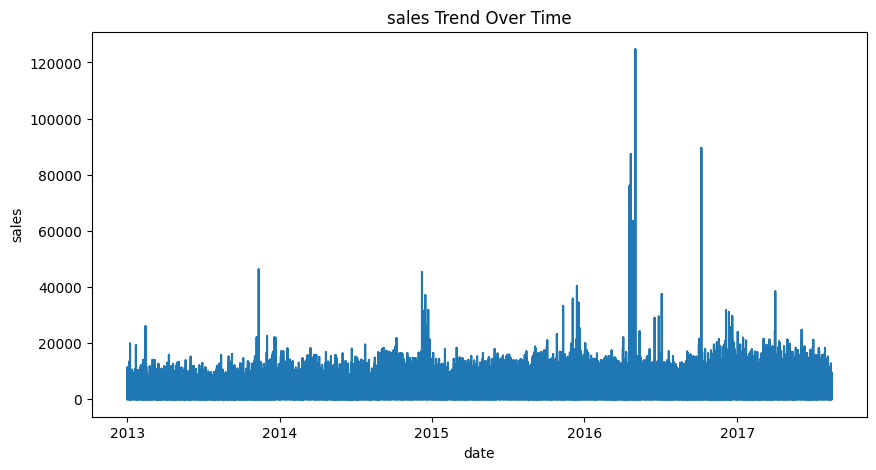

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'])
plt.title("sales Trend Over Time")
plt.xlabel("date")
plt.ylabel("sales")
plt.show()

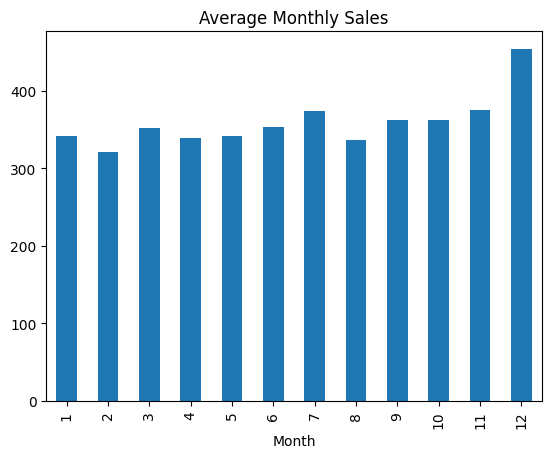

In [16]:
df['Month'] = df['date'].dt.month
monthly_sales = df.groupby('Month')['sales'].mean()

monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.show()

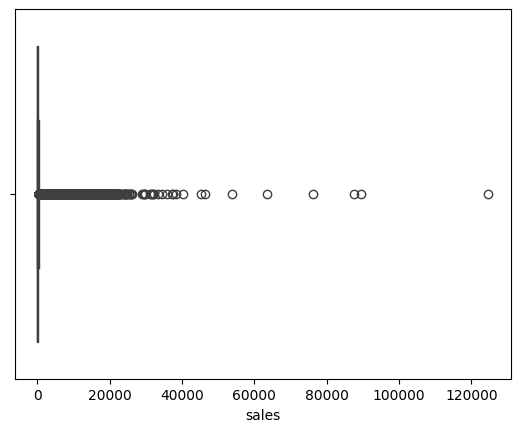

In [17]:
import seaborn as sns

sns.boxplot(x=df['sales'])
plt.show()

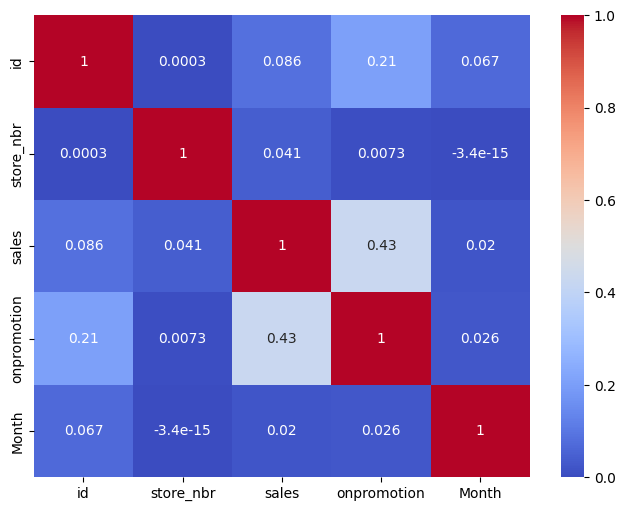

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [19]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

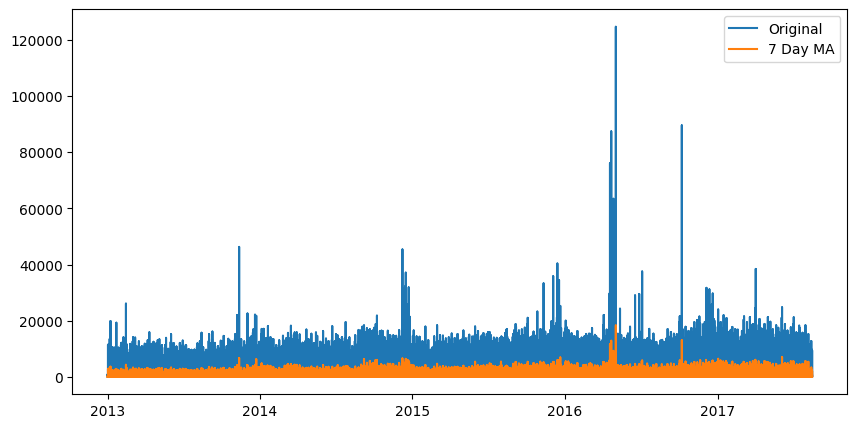

In [20]:
df['7_day_MA'] = df['sales'].rolling(window=7).mean()

plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'], label='Original')
plt.plot(df['date'], df['7_day_MA'], label='7 Day MA')
plt.legend()
plt.show()

In [21]:
df.to_csv("updated_train.csv", index=False)